In [3]:
from read_eqdsk_extended import read_eqdsk_extended
import numpy as np
import matplotlib.pyplot as plt
import os

eqdsk_file = os.path.join(os.getcwd(), '2026-02-10_iter_rampup_new/out/iter_new_i=0.eqdsk')

65


Text(0.5, 1.0, 'Volume vs psi_n for rampup eqdsk files')

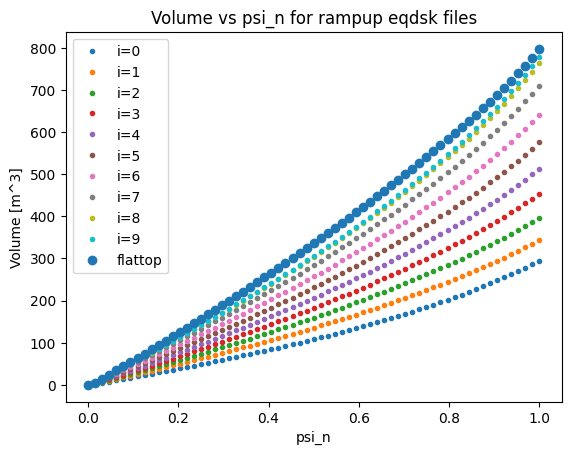

In [17]:
g_arr_rampup = [f'2026-02-10_iter_rampup_new/out/iter_new_i={i}.eqdsk' for i in range(0,10)] 

fig, ax = plt.subplots()

for i, eqdsk_file in enumerate(g_arr_rampup):
    tm_eqdsk = read_eqdsk_extended(eqdsk_file)
    ax.plot(tm_eqdsk['psi_n'], tm_eqdsk['vol'], '.', label=f'i={i}')

flattop_eqdsk = read_eqdsk_extended('2026-02-10_iter_rampup_new/out/flattop.eqdsk')

ax.plot(flattop_eqdsk['psi_n'], flattop_eqdsk['vol'], 'o', label='flattop')
print(len(flattop_eqdsk['psi_n']))
ax.legend()
ax.set_xlabel('psi_n')
ax.set_ylabel('Volume [m^3]')
ax.set_title('Volume vs psi_n for rampup eqdsk files')

In [ ]:
# load tm dict from eqdsk file
tm_eqdsk = read_eqdsk_extended(eqdsk_file)

tm = {
    'R': tm_eqdsk['rcentr'],
    'Z': tm_eqdsk['zaxis'],
    'B0': tm_eqdsk['bcentr'],
    'Ip': tm_eqdsk['ip'],
    'psi_axis': tm_eqdsk['psimag'],
    'psi_lcfs': tm_eqdsk['psibry'],

    'q_prof': tm_eqdsk['qpsi'],
    'q_axis': tm_eqdsk['qpsi'][0],
    'q_lcfs': tm_eqdsk['qpsi'][-1],

    'vol': tm_eqdsk['vol'],
    'vol_lcfs': tm_eqdsk['vol_lcfs'],
    'vpr': tm_eqdsk['vpr'],
    'R_inv_avg': tm_eqdsk['R_inv_avg'],
    'R_avg': tm_eqdsk['R_avg'],

    'psi_N': tm_eqdsk['psi_n'],
    'psi': tm_eqdsk['psi'],
}


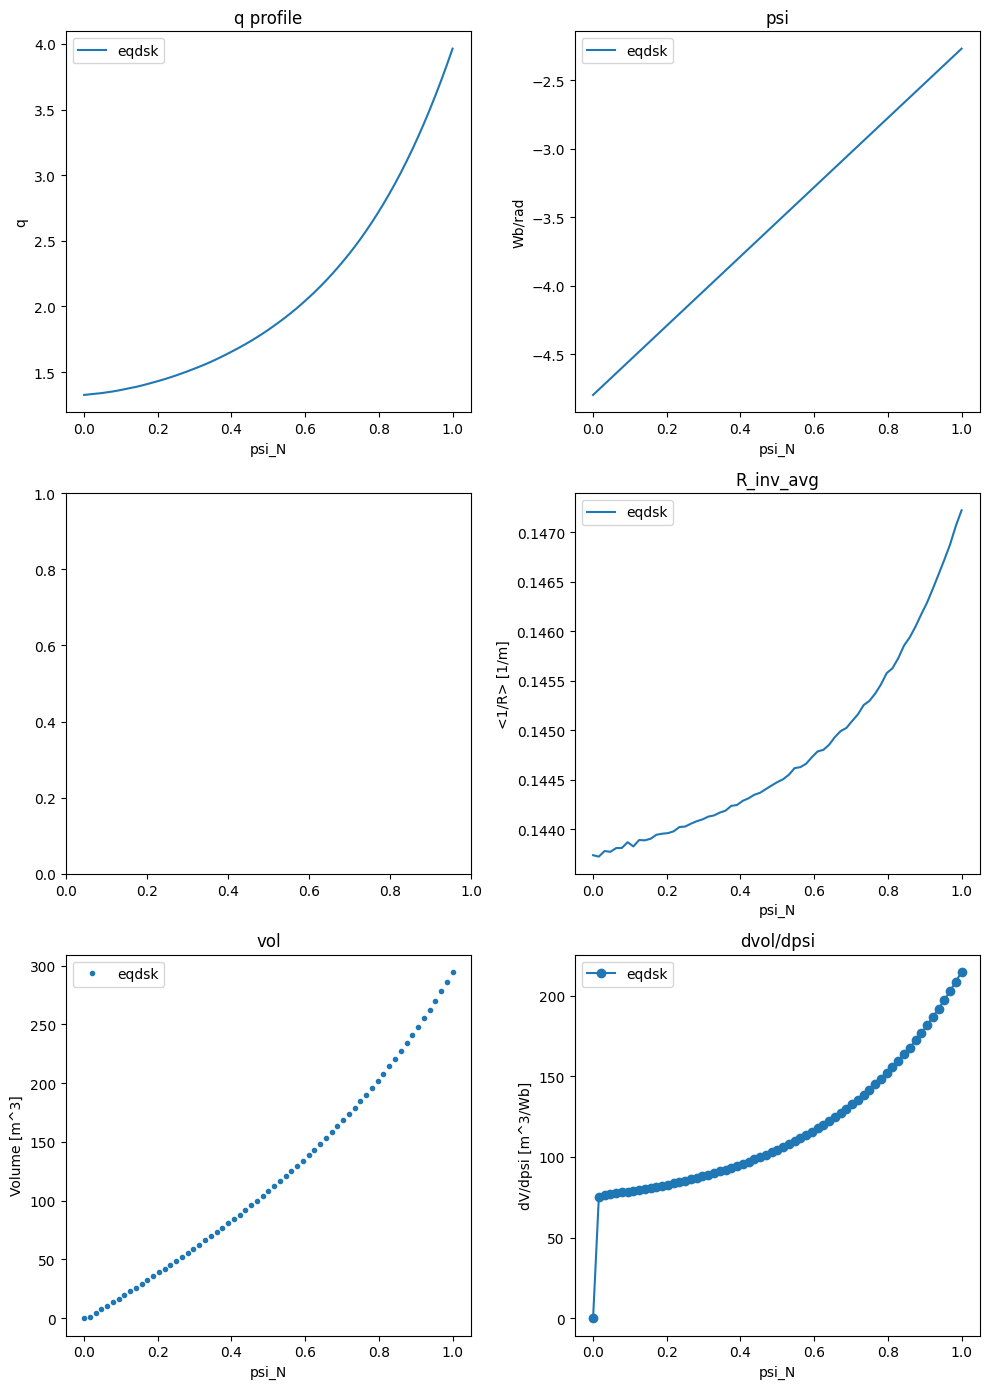

In [11]:
# Profile comparison plots
fig, axes = plt.subplots(3,2,figsize=(10,14))
# fig.suptitle(f'eqdsk v TORAX profiles: {eqdsk_file} \n ', fontsize=16)

ax00 = axes[0,0]
ax01 = axes[0,1]
ax10 = axes[1,0]
ax11 = axes[1,1]
ax20 = axes[2,0]
ax21 = axes[2,1]

ax00.set_title('q profile')
ax00.plot(tm['psi_N'], tm['q_prof'], label='eqdsk')
# ax00.plot(tx['psi_N'], tx['q_prof'], 'r--', label='TX')
ax00.set_ylabel('q')
ax00.set_xlabel('psi_N')
ax00.legend()

ax01.set_title('psi')
ax01.plot(tm['psi_N'], tm['psi'], label='eqdsk')
# ax01.plot(tx['psi_N'], tx['psi'], 'r--', label='TX/2pi')
# ax01.plot(tx['psi_N'], tx['psi_from_Ip'], '-.', label = 'TX psi from Ip/2pi')
# ax01.plot(tx['psi_N'], tx['psi_from_geo'], ':', label = 'TX psi from geo/2pi')
ax01.set_ylabel('Wb/rad')
ax01.set_xlabel('psi_N')
ax01.legend()

# ax10.set_title('R_avg')
# ax10.plot(tm['psi_N'], tm['R_avg'], label='eqdsk')
# ax10.plot(tx['psi_N'], tx['R_inv_avg'], 'r--', label='TX (not available)', alpha=0.3)
# ax10.legend()

ax11.set_title('R_inv_avg')
ax11.plot(tm['psi_N'], tm['R_inv_avg'], label='eqdsk')
# ax11.plot(tx['psi_N'], tx['R_inv_avg'], 'r--', label='TX')
ax11.set_ylabel('<1/R> [1/m]')
ax11.set_xlabel('psi_N')
ax11.legend()

ax20.set_title('vol')
ax20.plot(tm['psi_N'], tm['vol'],'.', label='eqdsk')
# ax20.plot(tx['psi_N'], tx['vol'], 'r--', label='TX')
ax20.set_ylabel('Volume [m^3]')
ax20.set_xlabel('psi_N')
ax20.legend()

ax21.set_title('dvol/dpsi')
ax21.plot(tm['psi_N'], tm['vpr'], label='eqdsk', marker='o')
# ax21.plot(tx['psi_N'], tx['vpr'], 'r--', label='TX')
# ax21.text(0.3,500, 'Unsure of units from TORAX')
ax21.set_ylabel('dV/dpsi [m^3/Wb]')
ax21.set_xlabel('psi_N')
ax21.legend()

fig.tight_layout()
